In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')
 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 대학원 합격 예측 데이터 셋
[대학원 합격 예측 데이터셋 링크](https://www.kaggle.com/datasets/mohansacharya/graduate-admissions)

## 컬럼 상세 설명
| 컬럼명 | 데이터 타입 | 데이터 범위 | 설명 |
| :--- | :--- | :--- | :--- |
| **`Serial No.`** | 정수 (Int) | $1 \sim 500$ | 학생 식별용 고유 번호 |
| **`GRE Score`** | 정수 (Int) | $290 \sim 340$ 점 | 미국 대학원 입학 시험(GRE) 점수 |
| **`TOEFL Score`** | 정수 (Int) | $92 \sim 120$ 점 | 공인 영어 능력 평가(TOEFL) 점수 |
| **`University Rating`** | 정수 (Int) | $1 \sim 5$ 단계 | 지원/출신 대학의 명성 레벨 ($1$: 낮음 $\sim$ $5$: 최고) |
| **`SOP`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 자기소개서/학업계획서(Statement of Purpose) 점수 |
| **`LOR`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 교수 추천서(Letter of Recommendation) 점수 |
| **`CGPA`** | 실수 (Float) | $6.80 \sim 9.92$ | 학부 평균 학점 (Cumulative GPA, 10점 만점 기준) |
| **`Research`** | 정수 (Int) | $0$ 또는 $1$ | 학부 연구 참여 및 논문 작성 경험 ($0$: 없음, $1$: 있음) |
| **`Chance of Admit`** | 정수 (Int) | $0$ 또는 $1$ | 합격 1, 불합격 0 |

In [5]:
import os
import pandas as pd

base_path = "/Users/hyusoohi5/kdt_0900_khs/ml/resource/"
file_name = "admission_predict .csv"

file_path = os.path.join(base_path, file_name)

print(file_path)
print(os.path.exists(file_path))

df = pd.read_csv(file_path)
df.head()

/Users/hyusoohi5/kdt_0900_khs/ml/resource/admission_predict .csv
True


,Unnamed: 0,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,0,1,337,118,4,4.5,4.5,9.65,1,1
1,1,2,324,107,4,4.0,4.5,8.87,1,1
2,2,3,316,104,3,3.0,3.5,8.00,1,0
3,3,4,322,110,3,3.5,2.5,8.67,1,1
4,4,5,314,103,2,2.0,3.0,8.21,0,0


In [65]:
admission_df = df.drop("Unnamed: 0", axis=1)
admission_df = df.drop(["Unnamed: 0", "Serial No."], axis=1)
admission_df.columns = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Target']

admission_df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Target
0,337,118,4,4.5,4.5,9.65,1,1
1,324,107,4,4.0,4.5,8.87,1,1
2,316,104,3,3.0,3.5,8.00,1,0
3,322,110,3,3.5,2.5,8.67,1,1
4,314,103,2,2.0,3.0,8.21,0,0


### 1단계, 데이터 전처리

In [8]:
# 삭제해야 할 데이터 : Unnamed:0
# 수치형 : GRE Score, TOEFL Score, SOP, LOR, CGPA
# 분류형 : Serial No., University Rating, Research, Chance of Admit

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         400 non-null    int64  
 1   Serial No.         400 non-null    int64  
 2   GRE Score          400 non-null    int64  
 3   TOEFL Score        400 non-null    int64  
 4   University Rating  400 non-null    int64  
 5   SOP                400 non-null    float64
 6   LOR                400 non-null    float64
 7   CGPA               400 non-null    float64
 8   Research           400 non-null    int64  
 9   Chance of Admit    400 non-null    int64  
dtypes: float64(3), int64(7)
memory usage: 31.4 KB


In [66]:
df.describe()

,Unnamed: 0,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,199.500000,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.450000
std,115.614301,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.498117
min,0.000000,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.000000
25%,99.750000,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.000000
50%,199.500000,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.000000
75%,299.250000,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,1.000000
max,399.000000,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,1.000000


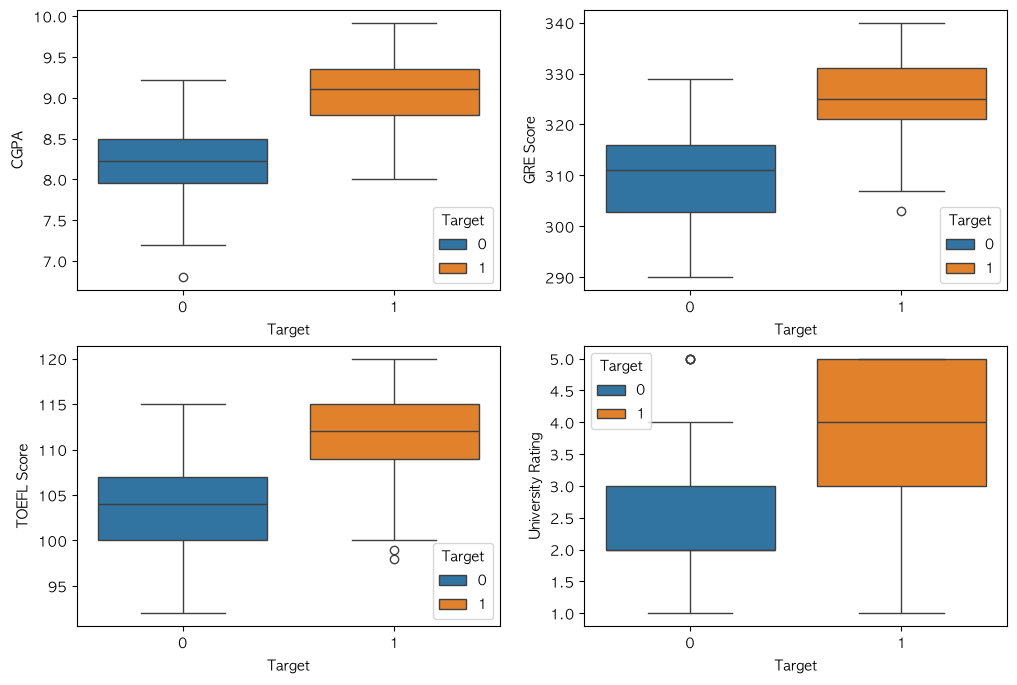

In [68]:
features = ["CGPA", "GRE Score", "TOEFL Score", "University Rating"]

plt.figure(figsize=(12, 8))
for i, features in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(admission_df, x="Target", y=features, hue="Target")

plt.show()

In [69]:
# 상관관계 분석
corr_matrix = admission_df.corr(numeric_only=True)
corr_matrix

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Target
GRE Score,1.000000,0.835977,0.668976,0.612831,0.557555,0.833060,0.580391,0.686138
TOEFL Score,0.835977,1.000000,0.695590,0.657981,0.567721,0.828417,0.489858,0.672465
University Rating,0.668976,0.695590,1.000000,0.734523,0.660123,0.746479,0.447783,0.638983
SOP,0.612831,0.657981,0.734523,1.000000,0.729593,0.718144,0.444029,0.612152
LOR,0.557555,0.567721,0.660123,0.729593,1.000000,0.670211,0.396859,0.557481
CGPA,0.833060,0.828417,0.746479,0.718144,0.670211,1.000000,0.521654,0.737307
Research,0.580391,0.489858,0.447783,0.444029,0.396859,0.521654,1.000000,0.519441
Target,0.686138,0.672465,0.638983,0.612152,0.557481,0.737307,0.519441,1.000000


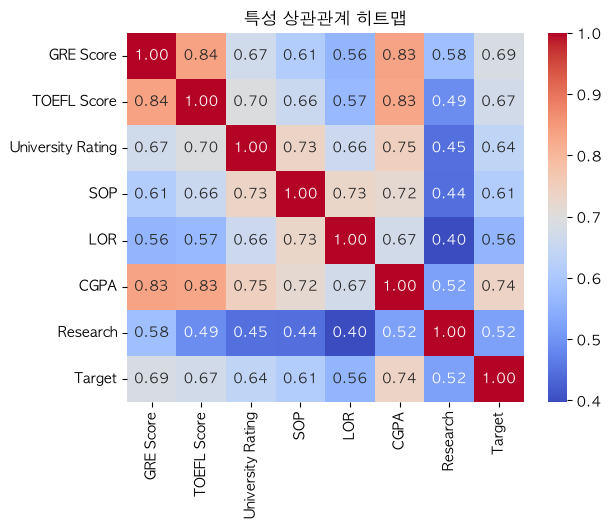

In [71]:
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("특성 상관관계 히트맵")
plt.show()

In [72]:
# 다중공선성 판별
## 이게 뭘 판별하는 과정인가? -- 바로, 독립변수 간의 관계성을 판별하는 과정!!
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [74]:
X = admission_df.drop("Target", axis=1)
X.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0


In [76]:
y = admission_df["Target"]
y.head()

0    1
1    1
2    0
3    1
4    0
Name: Target, dtype: int64

In [79]:
# CGPA 컬럼을 주요깊게 볼 필요 있음 !!
vif = [variance_inflation_factor(X.values, i)for i in range(X.shape[1])]

print(vif)
print(X.columns)

[np.float64(4.615516166781605), np.float64(4.2889590137468945), np.float64(2.9196056618253405), np.float64(3.075503721954348), np.float64(2.4312584848694407), np.float64(5.207402545736424), np.float64(1.5433119011502872)]
Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA',
       'Research'],
      dtype='str')


In [82]:
# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(320, 7) (80, 7) (320,) (80,)


In [152]:
# Ridge : 선형 모델에서 오차값이 너무 튀지 않게 (기울기가 너무 급등(락)하지 않게) 하기 위해 규제하는 메서드 (선호!!)
# Rasso : 기울기를 절대값으로 만들고, 영향을 주지 않는다면 0으로 만들어버리는 메서드
# mean_squared_error : 예측값들마다의 잔차가 얼마나 떨어져 있는지를 확인할 수 있는 메서드

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

## 규제(regularization)
- 머신러닝 모델이 train 세트를 너무 과도하게 학습하지 못하도록 훼방하는 것
- 선형회귀 모델의 경우 특성에 곱해지는 계수 또는 기울기의 크기를 작게 만드는 일이다.
- 쉽게 말하자면 선형회귀 모델의 성능을 끌어올리기 위한 방법이다.
- 
#### 1) 릿지(ridge)
- 계수를 제곱한 값을 기준으로 규제를 적용한다. (일반적으로 선호)
- 조금 넘을 때는 벌금이 적지만, 과속이 심해질수록 벌금이 제곱으로 폭발하도록 설계된다.  
  즉, 작은 값으로 연산하여 값이 폭발하는 것을 방지함.
- 예를 들어 $z = (2.5 \times 100) + b = 250 + b$를
- $z = (0.008 \times 100) + b = 0.8 + b$


#### 2) 라쏘(lasso)
- 계수의 절댓값을 기준으로 규제를 적용한다. 영향을 주지 않는 가중치는 과감하게 빼버림 (가중치가 작든 크든 줄어드는 비율이 일정)
- $z = $$z = w_1 \cdot (\text{연봉}) + w_2 \cdot (\text{나이}) + w_3 \cdot (\text{성별}) + b$$
- $z = $$z = w_1 \cdot (\text{연봉}) + 0 \cdot (\text{나이}) + 0 \cdot (\text{성별}) + b$$

In [105]:
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [112]:
models = {
    "LinearRegression" : LinearRegression(),
    "Ridge" : Ridge(alpha=1.0),
    "Lasso" : Lasso(alpha=0.01)
}

result = []
coef_df = pd.DataFrame(index=X.columns)

for name, model in models.items():
    # 학습
    model.fit(X_train_scaler, y_train)
    # 예측
    y_pred = model.predict(X_test_scaler)
    # 평가
    mse = mean_squared_error(y_test,  y_pred)
    rmse = np.sqrt(mse)
    y_pred_class = (y_pred >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred_class)

    result.append({
        "Model" : name, 
        "MSE" : mse,
        "RMSE" : rmse,
        "Accuracy" : acc
    })
    
    coef_df[name] = model.coef_

In [117]:
coef_df.sort_values(by="LinearRegression", ascending=False)

,LinearRegression,Ridge,Lasso
CGPA,0.170626,0.168599,0.169111
GRE Score,0.076086,0.076236,0.075305
University Rating,0.069660,0.069725,0.066634
Research,0.064450,0.064335,0.058810
SOP,0.055002,0.054779,0.048769
TOEFL Score,0.009755,0.010982,0.008198
LOR,-0.004585,-0.003801,0.000000


In [114]:
result_df = pd.DataFrame(result)
result_df

,Model,MSE,RMSE,Accuracy
0,LinearRegression,0.101292,0.318264,0.8625
1,Ridge,0.101213,0.318139,0.8625
2,Lasso,0.101332,0.318326,0.8875


In [129]:
X_test_scaler_df = pd.DataFrame(X_test_scaler, columns=X_test.columns, index=X_test.index)

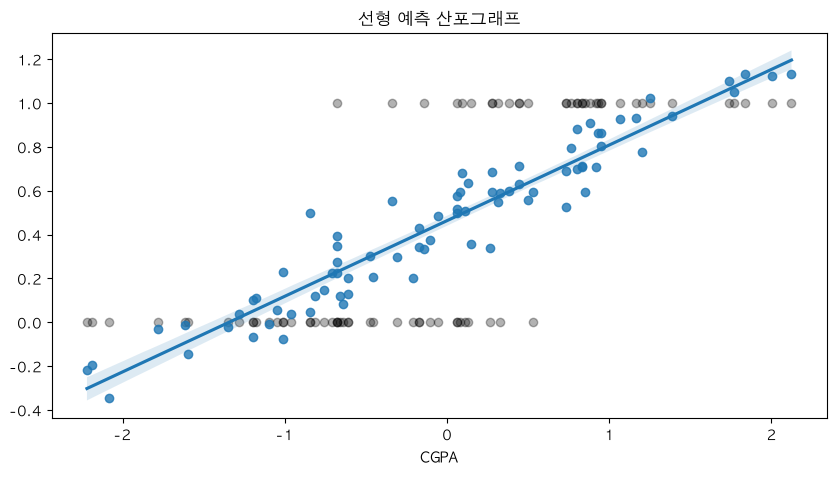

In [136]:
# 정답률
# 위에가 합격 (위에 올라간 애들은 모두 1로 표시)
# 밑에가 불합격 (아래로 내려간 애들은 모두 0으로 표시)

plt.figure(figsize=(10, 5))
plt.scatter(X_test_scaler_df["CGPA"], y_test, color="black", alpha=0.3, label="Actual")
sns.regplot(x=X_test_scaler_df["CGPA"], y=model.predict(X_test_scaler))

plt.title("선형 예측 산포그래프")
plt.show()

In [137]:
lr = LogisticRegression()

In [138]:
lr.fit(X_train_scaler, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [139]:
y_pred = lr.predict(X_test_scaler)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0])

In [147]:
y_prob = lr.predict_proba(X_test_scaler)[:, 1]
y_prob_percent = y_prob * 100

for i, proba in enumerate(y_prob_percent[:20],1):
    print(f"샘플{i}번의 확률 : {proba:.2f}%")

샘플1번의 확률 : 98.86%
샘플2번의 확률 : 5.62%
샘플3번의 확률 : 6.88%
샘플4번의 확률 : 0.09%
샘플5번의 확률 : 0.24%
샘플6번의 확률 : 14.38%
샘플7번의 확률 : 24.86%
샘플8번의 확률 : 0.24%
샘플9번의 확률 : 6.15%
샘플10번의 확률 : 99.88%
샘플11번의 확률 : 80.96%
샘플12번의 확률 : 0.35%
샘플13번의 확률 : 96.18%
샘플14번의 확률 : 99.66%
샘플15번의 확률 : 98.39%
샘플16번의 확률 : 89.61%
샘플17번의 확률 : 75.23%
샘플18번의 확률 : 0.29%
샘플19번의 확률 : 52.76%
샘플20번의 확률 : 94.89%


In [151]:
acc = accuracy_score(y_test, y_pred)
print(f"로지스틱 회귀 정확도 : {acc:.2f}")

로지스틱 회귀 정확도 : 0.89


In [153]:
coef_df = pd.DataFrame({
    "Features" : X_train.columns,
    "Coef" : lr.coef_[0]
}).sort_values(by="Coef", ascending=False)

coef_df

,Features,Coef
5,CGPA,1.752864
0,GRE Score,0.662403
3,SOP,0.627480
2,University Rating,0.506172
6,Research,0.357107
1,TOEFL Score,0.324889
4,LOR,0.146161


Text(0, 0.5, '가중치')

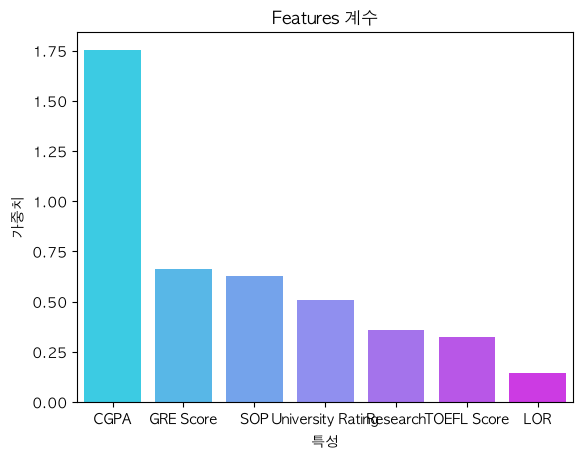

In [163]:
sns.barplot(coef_df, x="Features", y="Coef", hue="Features", palette="cool")
plt.title("Features 계수")
plt.xlabel("특성")
plt.ylabel("가중치")

In [165]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.86      0.89        44
           1       0.85      0.92      0.88        36

    accuracy                           0.89        80
   macro avg       0.89      0.89      0.89        80
weighted avg       0.89      0.89      0.89        80

